# Visualisation du DataFrame

Dans ce document, il sera question de visualiser les données propres que nous avons générées.

Le plan d'action est donc le suivant :
- Importation des Librairies
- Histogramme des Colonnes

# 1. Importation des Librairies

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium 
from folium.plugins import MarkerCluster
from sklearn.discriminant_analysis import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Les librairies ont été installées correctement !')

file_path = './data/processed/final.csv'
df = pd.read_csv(file_path)

print('Le fichier du DataFrame final a été chargé avec succès !')

Les librairies ont été installées correctement !
Le fichier du DataFrame final a été chargé avec succès !


## 2. Histogramme des Colonnes

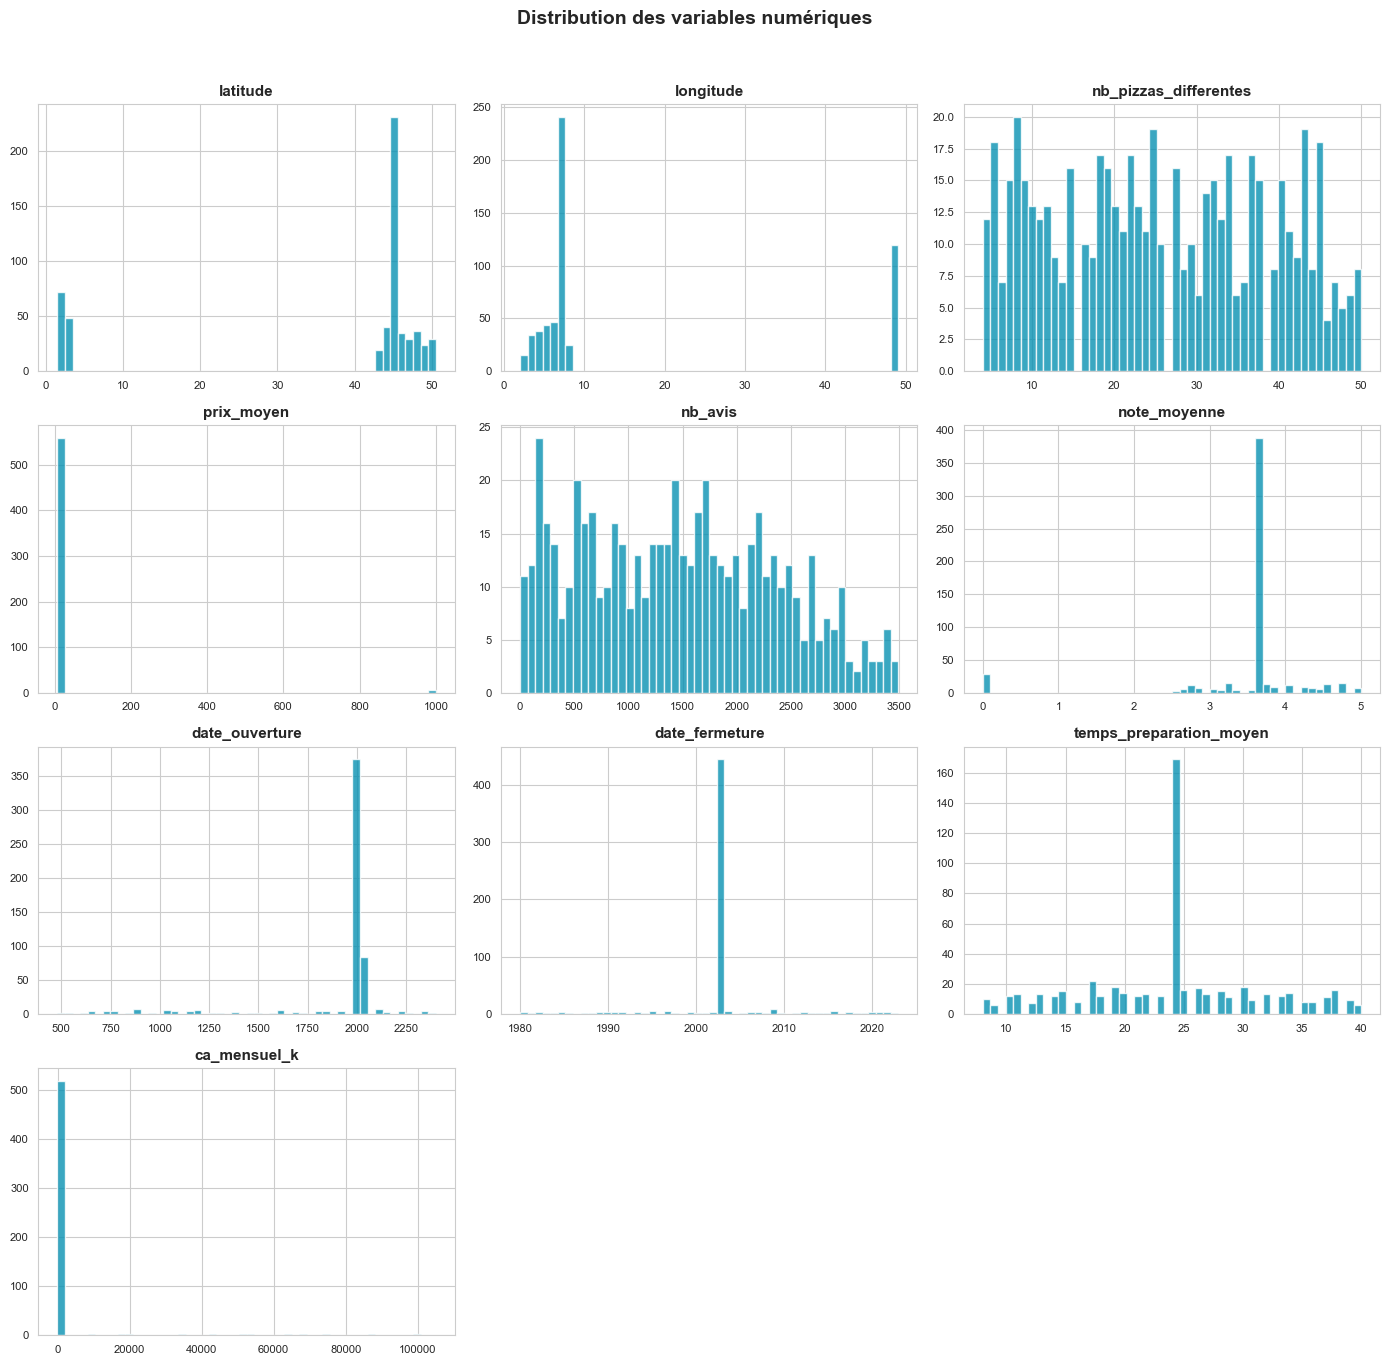

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Histogrammes de toutes les variables numériques
n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 10 / 3))
axes = np.array(axes).flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=50, ax=axes[i], color='#0891B2', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].tick_params(labelsize=8)

# On masque les axes vides si le nombre de colonnes n'est pas un multiple de ncols
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables numériques', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Matrice de Corrélation

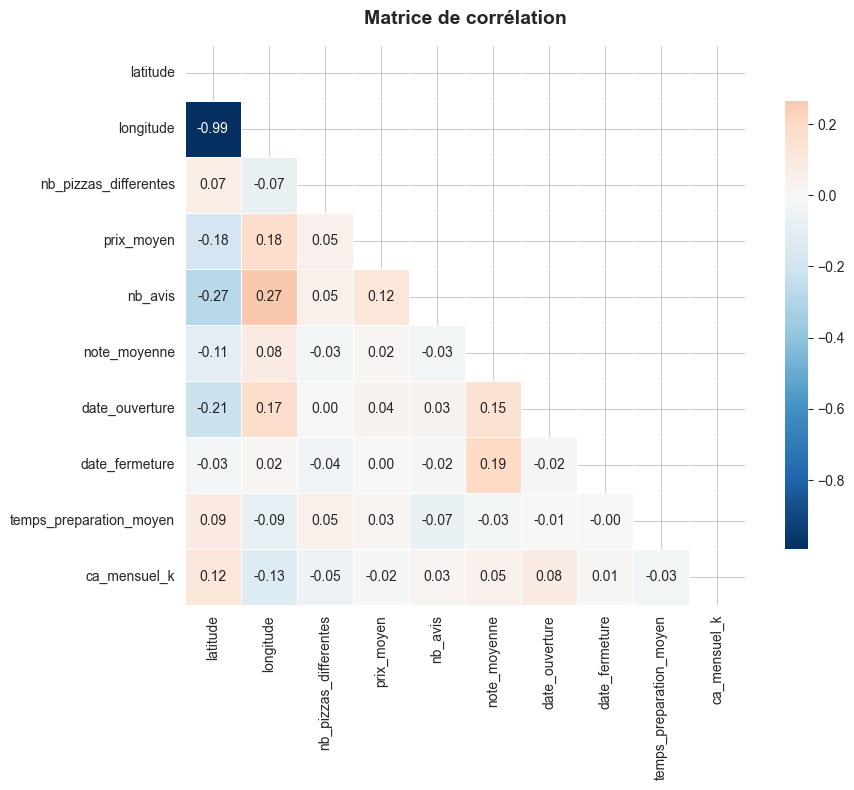

In [3]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Matrice de corrélation', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 4. K-Means

### 4.1. Données d'Entraînement

In [4]:
# On sélection des features pour le clustering
features_for_clustering = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Features utilisées ({len(features_for_clustering)}) :')
print(features_for_clustering)
print()

# On définit un nouveau DataFrame sur lequel travailler
X = df[features_for_clustering].copy()

# On normalise les données numériques pour que le clustering ne soit pas biaisé par les échelles différentes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Visualisation des données d\'entraînement :')
print(X_scaled)

Features utilisées (10) :
['latitude', 'longitude', 'nb_pizzas_differentes', 'prix_moyen', 'nb_avis', 'note_moyenne', 'date_ouverture', 'date_fermeture', 'temps_preparation_moyen', 'ca_mensuel_k']

Visualisation des données d'entraînement :
[[ 0.64492899 -0.47080375  0.87606778 ... -0.65623657  0.01647738
  -0.25461194]
 [ 0.74162968 -0.54456031 -0.26645317 ...  1.07733451  0.01647738
  -0.25564843]
 [ 0.65748592 -0.47417924 -0.79962962 ...  0.55726319  0.01647738
  -0.2581482 ]
 ...
 [ 0.46465533 -0.47513343  0.4190594  ...  0.03719186  1.87512589
  -0.25589231]
 [ 0.46465533 -0.47513343 -0.87579768 ...  0.03719186 -0.64732566
  -0.25497776]
 [ 0.46465533 -0.47513343  0.64756359 ...  0.03719186 -0.51456505
  -0.25869694]]


### 4.2. Application de l'Algorithme

In [5]:
# On applique l'algorithme de K-Means sur k=2
kmeans_elbow = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster'] = kmeans_elbow.fit_predict(X_scaled)
print('Clustering K-Means effectué avec succès !')

Clustering K-Means effectué avec succès !


### 4.3 Visualisation sous forme de figure

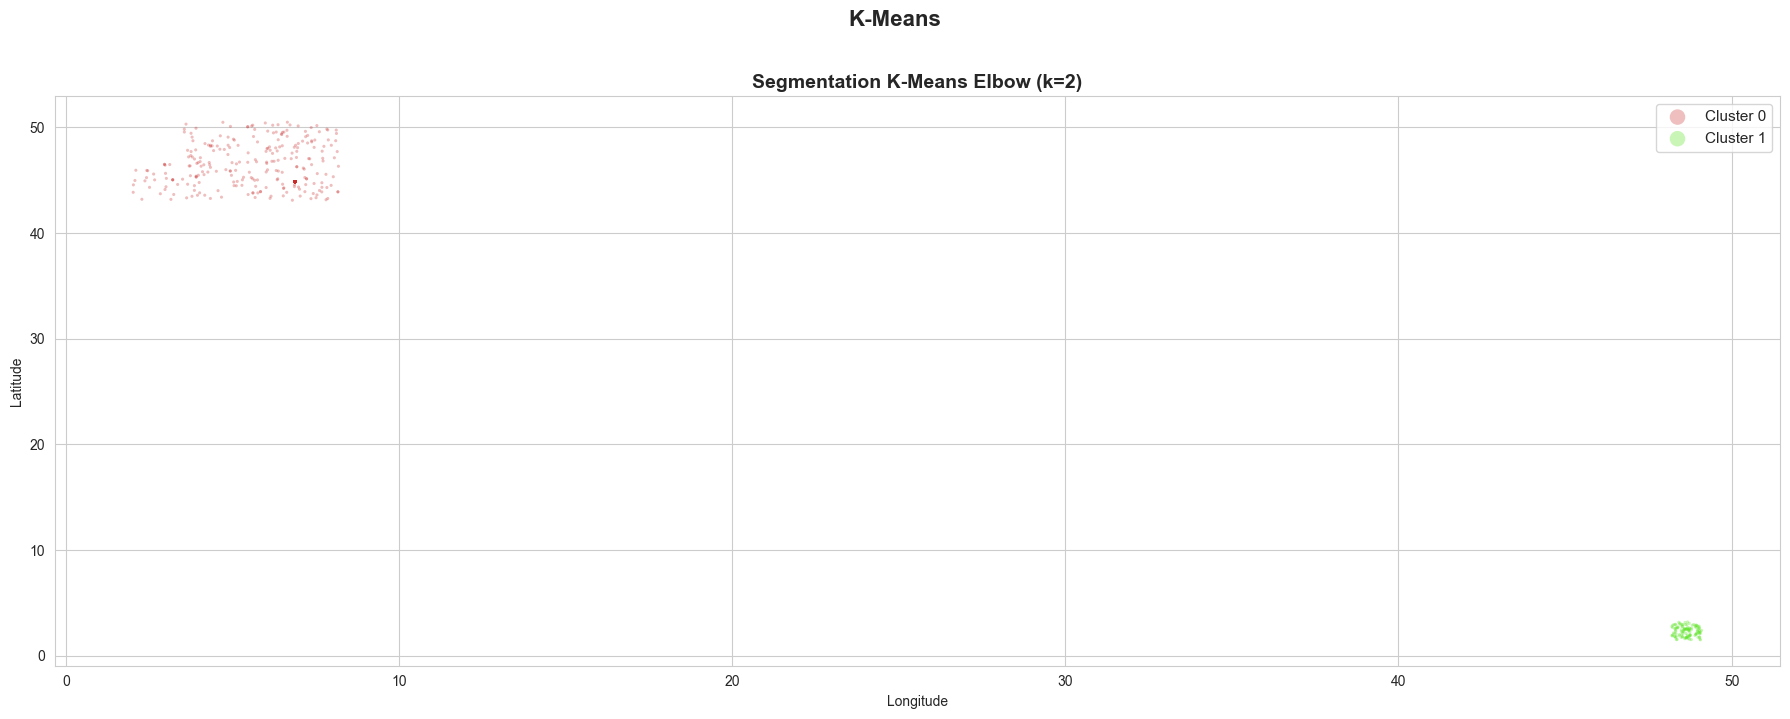

In [6]:
# Figure    
fig, ax = plt.subplots(1, 1, figsize=(18, 7))
available_colors = ['#ca2b2b', '#4ee212', '#1f88d6', '#ca2bb3']

# Clusters
for cluster_id in range(2):
    mask = df['cluster'] == cluster_id
    ax.scatter(df.loc[mask, 'longitude'], df.loc[mask, 'latitude'], c=available_colors[cluster_id], alpha=0.3, s=5, label=f'Cluster {cluster_id}', edgecolors='none')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Segmentation K-Means Elbow (k=2)', fontsize=14, fontweight='bold')
ax.legend(markerscale=5, fontsize=11)

plt.suptitle('K-Means', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.4. Visualisation sous forme de carte

In [7]:
# Carte géographique colorée par cluster
latitude = df['latitude'].median()
longitude = df['longitude'].median()
df_map = folium.Map(location=[latitude, longitude], zoom_start=10)

marker_cluster = MarkerCluster().add_to(df_map)
for idx, row in df.iterrows():
    folium.Marker(location=[row['latitude'], row['longitude']],
                  popup=f"Prix Moyen: {row['prix_moyen']}€").add_to(marker_cluster)

df_map